In [ ]:
# Part 1: Diagnostic DSL 
# Part 2: DSL Regression 
#
# Reference: Egami, N., Hinck, M., Stewart, B. M., & Wei, H. (2024)

In [2]:
# Load libraries 
library(dsl)
library(tidyverse)
library(readxl) 

# DSL Regression Analysis

In [ ]:
# -----------------------------------------------------------------------------
# CONFIGURATION
# -----------------------------------------------------------------------------

# File paths
LLM_PATH <- "/Users/FrederikkeB/Documents/GitHub/misleading-climate-claims-dk/data/annotated/llm_18k_annotated.csv"
MANUAL_PATH <- "/Users/FrederikkeB/Documents/GitHub/misleading-climate-claims-dk/data/annotated/manual_500_annotated.xlsx"
OUTPUT_DIR <- "/Users/FrederikkeB/Documents/GitHub/misleading-climate-claims-dk/data"


# Superclaim definitions
SUPERCLAIM_NAMES <- c(
  "0" = "No claim detected",
  "1" = "Global warming not happening",
  "2" = "Humans not causing climate change",
  "3" = "Climate impacts not bad",
  "4" = "Climate solutions harmful/unnecessary",
  "5" = "Climate science unreliable",
  "6" = "Climate proponents alarmist/biased",
  "7" = "We need fossil fuels"
)

SUPERCLAIMS <- 0:7

In [19]:
# -----------------------------------------------------------------------------
# DATA LOADING AND PARSING
# -----------------------------------------------------------------------------

# Parse functions 
parse_llm_claims <- function(val) {
  if (is.na(val)) return(integer(0))
  clean <- gsub("\\[|\\]", "", val)
  if (clean == "" || clean == " ") return(integer(0))
  claims <- as.integer(strsplit(clean, ",\\s*")[[1]])
  return(claims[!is.na(claims)])
}
 
parse_manual_claims <- function(val) {
  if (is.na(val)) return(integer(0))
  parts <- strsplit(as.character(val), ";\\s*")[[1]]
  claims <- sapply(parts, function(p) {
    prefix <- strsplit(p, "_")[[1]][1]
    as.integer(prefix)
  })
  return(unique(claims[!is.na(claims)]))
}
 
# Load data
llm_raw <- read_csv(LLM_PATH, show_col_types = FALSE)
manual_raw <- read_excel(MANUAL_PATH, sheet="dsl")
 
cat(sprintf("LLM annotations loaded:    %s articles\n", format(nrow(llm_raw))))
cat(sprintf("Manual annotations loaded: %s articles\n", format(nrow(manual_raw))))
 
# Parse claims
llm_raw <- llm_raw %>%
  mutate(claims_parsed = map(CardsClaim, parse_llm_claims))
 
manual_raw <- manual_raw %>%
  mutate(claims_parsed = map(HumanClaim, parse_manual_claims))
 
# Create binary indicators
for (s in SUPERCLAIMS) {
  llm_raw[[paste0("llm_", s)]] <- map_int(llm_raw$claims_parsed, ~as.integer(s %in% .x))
  manual_raw[[paste0("manual_", s)]] <- map_int(manual_raw$claims_parsed, ~as.integer(s %in% .x))
}
 
# Merge
merged <- llm_raw %>%
  left_join(
    manual_raw %>% select(ArticleKey, starts_with("manual_")),
    by = "ArticleKey"
  )
 
cat(sprintf("\nMerged dataset: %s articles total & %s in validation sample\n", 
            nrow(merged), sum(!is.na(merged$manual_0))))

New names:
• `` -> `...1`


LLM annotations loaded:    17975 articles
Manual annotations loaded: 500 articles

Merged dataset: 17975 articles total & 499 in validation sample


## PART 1: PREVALENCE ESTIMATION

In [21]:
# -----------------------------------------------------------------------------
# PART 1: PREVALENCE ESTIMATION
# -----------------------------------------------------------------------------
 
cat("\n" %+% strrep("=", 80) %+% "\n")
cat("PART 1: PREVALENCE ESTIMATION\n")
cat(strrep("=", 80) %+% "\n\n")
 
# Initialize results storage
prevalence_results <- tibble()
 
# Compute DSL estimates for each superclaim using dsl() package
for (s in SUPERCLAIMS) {
  cat(sprintf("Computing DSL estimate for superclaim %d using dsl()...\n", s))
  
  # Variable names
  manual_var <- paste0("manual_", s)
  llm_var <- paste0("llm_", s)
  
  # Run DSL with intercept-only model (intercept = mean = prevalence)
  dsl_model <- dsl(
    model = "lm",
    formula = as.formula(paste0(manual_var, " ~ 1")),  # Intercept-only
    predicted_var = manual_var,
    prediction = llm_var,
    data = merged
  )
  
  # Extract values from dsl object components 
  dsl_estimate <- dsl_model$coefficients["(Intercept)"]
  se <- dsl_model$standard_errors["(Intercept)"]
  
  # Calculate 95% CI manually from coefficient and SE
  ci_lower <- dsl_estimate - 1.96 * se
  ci_upper <- dsl_estimate + 1.96 * se
  
  # Also compute CARDS and manual means for comparison
  cards_mean <- mean(merged[[llm_var]], na.rm = TRUE)
  manual_mean <- mean(merged[[manual_var]], na.rm = TRUE)
  bias <- cards_mean - manual_mean
  
  # Store results
  prevalence_results <- bind_rows(prevalence_results, tibble(
    superclaim = s,
    name = SUPERCLAIM_NAMES[as.character(s)],
    cards_estimate = cards_mean,
    manual_estimate = manual_mean,
    bias = bias,
    dsl_estimate = max(dsl_estimate, 0),  # Floor at 0
    se = se,
    ci_lower = max(ci_lower, 0),  # Floor at 0
    ci_upper = ci_upper
  ))
}
 
cat("\nDSL prevalence estimation complete.\n\n")
 
# Display results (matching Python output format)
cat("DSL PREVALENCE ESTIMATES:\n")
cat(strrep("=", 80), "\n")
 
prevalence_display <- prevalence_results %>%
  mutate(
    Superclaim = paste0(superclaim, ": ", name),
    `CARDS (%)` = sprintf("%.1f", cards_estimate * 100),
    `Manual (%)` = sprintf("%.1f", manual_estimate * 100),
    `Bias (pp)` = sprintf("%+.1f", bias * 100),
    `DSL estimate (%)` = sprintf("%.1f", dsl_estimate * 100),
    `95% CI` = sprintf("[%.1f, %.1f]", ci_lower * 100, ci_upper * 100)
  ) %>%
  select(Superclaim, `CARDS (%)`, `Manual (%)`, `Bias (pp)`, 
         `DSL estimate (%)`, `95% CI`)
 
print(prevalence_display, n = Inf)

PART 1: PREVALENCE ESTIMATION
Computing DSL estimate for superclaim 0 using dsl()...
Cross-Fitting: 1/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”


2/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”


3/10..

...

9/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”


10/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”



DSL prevalence estimation complete.

DSL PREVALENCE ESTIMATES:
# A tibble: 8 × 6
  Superclaim    `CARDS (%)` `Manual (%)` `Bias (pp)` `DSL estimate (%)` `95% CI`
  <chr>         <chr>       <chr>        <chr>       <chr>              <chr>   
1 0: No claim … 5.1         90.2         -85.1       90.1               [87.5, …
2 1: Global wa… 15.7        0.2          +15.5       0.2                [0.0, 0…
3 2: Humans no… 2.6         0.2          +2.4        0.2                [0.0, 0…
4 3: Climate i… 16.0        0.2          +15.8       0.2                [0.0, 0…
5 4: Climate s… 82.1        8.2          +73.8       8.4                [6.0, 1…
6 5: Climate s… 1.9         0.8          +1.1        0.8                [0.0, 1…
7 6: Climate p… 3.0         1.2          +1.8        1.2                [0.2, 2…
8 7: We need f… 4.4         1.0          +3.4        1.0                [0.1, 1…


In [23]:
merged2 <- merged %>%
  mutate(
    # LLM-prediktion: 1 hvis nogen claim 1-7 er til stede
    pred_any_claim = as.integer(rowSums(select(., llm_1:llm_7)) > 0),
    
    # Manuel annotation: 1 hvis nogen claim 1-7 er til stede, NA hvis ikke annoteret
    any_claim = case_when(
      !is.na(manual_0) ~ as.integer(rowSums(select(., manual_1:manual_7)) > 0),
      TRUE ~ NA_integer_
    )
  )

In [25]:
# Print results
cols_to_convert <- c("cards_estimate", "manual_estimate", "bias", "dsl_estimate", "se", "ci_lower", "ci_upper")
 
output_df <- prevalence_results %>%
  mutate(across(all_of(cols_to_convert), ~.x * 100)) %>%
  rename(
    cards_pct = cards_estimate,
    manual_pct = manual_estimate,
    bias_pp = bias,
    dsl_pct = dsl_estimate,
    se_pct = se,
    ci_lower_pct = ci_lower,
    ci_upper_pct = ci_upper
  )

output_df

superclaim,name,cards_pct,manual_pct,bias_pp,dsl_pct,se_pct,ci_lower_pct,ci_upper_pct
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,No claim detected,5.068150,90.1803607,-85.112211,90.1187686,1.3337214,87.50467457,92.7328625
1,Global warming not happening,15.727399,0.2004008,15.526998,0.2056603,0.2006171,0.00000000,0.5988699
2,Humans not causing climate change,2.631433,0.2004008,2.431032,0.1983996,0.2006377,0.00000000,0.5916496
3,Climate impacts not bad,15.972184,0.2004008,15.771783,0.1986436,0.2006544,0.00000000,0.5919263
4,Climate solutions harmful/unnecessary,82.058414,8.2164329,73.841982,8.3848504,1.2211353,5.99142531,10.7782756
5,Climate science unreliable,1.874826,0.8016032,1.073223,0.8024518,0.3999666,0.01851734,1.5863863
6,Climate proponents alarmist/biased,2.981919,1.2024048,1.779515,1.2044483,0.4885349,0.24691998,2.1619767
7,We need fossil fuels,4.389430,1.0020040,3.387426,1.0101562,0.4468136,0.13440162,1.8859108


In [12]:
# Save to CSV 
OUTPUT_DIR <- "/Users/FrederikkeB/Documents/GitHub/misleading-climate-claims-dk/src"

write_csv(output_df, file.path(OUTPUT_DIR, "dsl_prevalence_results.csv"))
cat(sprintf("\nPrevalence results saved to %s\n", 
            file.path(OUTPUT_DIR, "dsl_prevalence_results.csv")))


✓ Prevalence results saved to /Users/FrederikkeB/Documents/GitHub/misleading-climate-claims-dk/data/dsl_prevalence_results.csv


### power analysis

Cross-Fitting: 1/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”


2/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”


3/10..

...

9/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”


10/10..

Warning message in cbind(0, diag(1/sd_X, ncol = length(sd_X), nrow = length(sd_X))):
“number of rows of result is not a multiple of vector length (arg 1)”



Power Analysis: 1/10..2/10..3/10..4/10..5/10..6/10..7/10..8/10..9/10..10/10..
Predicted Standard Errors:
     (Intercept)
499   0.15007391
600   0.13685991
700   0.12670661
800   0.11852220
900   0.11174288
1000  0.10600773
1500  0.08655138
2000  0.07495260
---


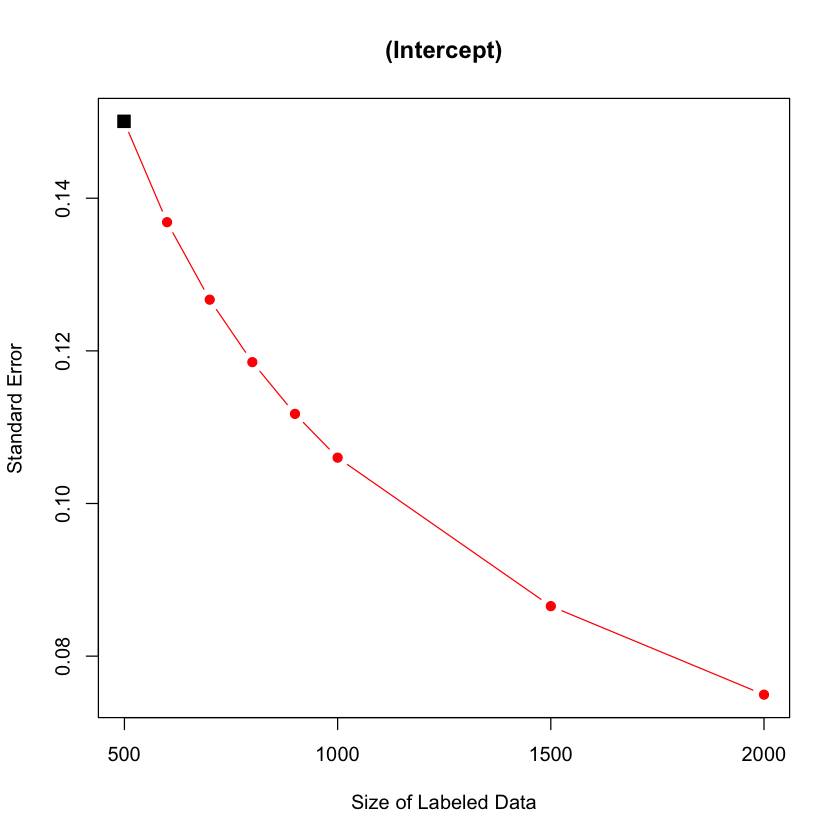

In [ ]:
power_out <- power_dsl(
  labeled_size = c(600, 700, 800, 900, 1000, 1500, 2000),
  model = "logit",
  formula = any_claim ~ 1,  
  predicted_var = "any_claim",
  prediction = "pred_any_claim",
  data = merged2
)

summary(power_out)
plot(power_out, coef_name = "(Intercept)")

## PART 2: PREPARE INFOMEDIA METADATA FOR REGRESSION

In [26]:
# -----------------------------------------------------------------------------
# PART 2: PREPARE DATA FOR REGRESSION
# -----------------------------------------------------------------------------
 
cat("\n\n", strrep("=", 80), "\n")
cat("PART 2: DSL REGRESSION - EXAMINING PATTERNS AND CONFOUNDERS\n")
cat(strrep("=", 80), "\n\n")
 
# Create outcome variable
merged <- merged %>%
  mutate(
    # Binary: any misleading claim (1-7) vs no claim (0)
    any_claim = if_else(manual_0 == 1, 0, 1),
    pred_any_claim = if_else(llm_0 == 1, 0, 1)
  )
 
cat("Outcome variable created:\n")
cat(sprintf("  LLM 'pred_any_claim': %.1f%% flagged\n", 
            mean(merged$pred_any_claim, na.rm = TRUE) * 100))
cat(sprintf("  Expert 'any_claim': %.1f%% flagged (validation sample)\n\n",
            mean(merged$any_claim, na.rm = TRUE) * 100))

# -----------------------------------------------------------------------------
# UNDERSTAND DATA STRUCTURE
# -----------------------------------------------------------------------------

cat("\n", strrep("-", 80), "\n")
cat("DATA STRUCTURE OVERVIEW\n")
cat(strrep("-", 80), "\n\n")

# Analyze outlet distribution
outlet_summary <- merged %>%
  group_by(Media) %>%
  summarise(
    n_articles = n(),
    pct_flagged_llm = mean(pred_any_claim, na.rm = TRUE) * 100
  ) %>%
  arrange(desc(n_articles))

cat(sprintf("Total unique outlets: %d\n", n_distinct(merged$Media)))
cat(sprintf("Outlets appearing once: %d (%.1f%%)\n", 
            sum(outlet_summary$n_articles == 1),
            100 * sum(outlet_summary$n_articles == 1) / nrow(outlet_summary)))
cat(sprintf("Outlets with 10+ articles: %d\n", 
            sum(outlet_summary$n_articles >= 10)))
cat(sprintf("Outlets with 50+ articles: %d\n\n", 
            sum(outlet_summary$n_articles >= 50)))

# Identify top 5 outlets
top_5_outlets <- outlet_summary %>%
  slice_max(n_articles, n = 5) %>%
  pull(Media)

cat("Top 5 outlets by article count:\n")
for (i in 1:5) {
  outlet_info <- outlet_summary %>% filter(Media == top_5_outlets[i])
  cat(sprintf("  %d. %-25s: %4d articles (%.1f%% flagged)\n",
              i, top_5_outlets[i], 
              outlet_info$n_articles, 
              outlet_info$pct_flagged_llm))
}



PART 2: DSL REGRESSION - EXAMINING PATTERNS AND CONFOUNDERS

Outcome variable created:
  LLM 'pred_any_claim': 94.9% flagged
  Expert 'any_claim': 9.8% flagged (validation sample)


 -------------------------------------------------------------------------------- 
DATA STRUCTURE OVERVIEW
-------------------------------------------------------------------------------- 

Total unique outlets: 814
Outlets appearing once: 116 (14.3%)
Outlets with 10+ articles: 276
Outlets with 50+ articles: 109

Top 5 outlets by article count:
  1. Ritzaus Bureau           :  455 articles (92.7% flagged)
  2. Fyens.dk                 :  297 articles (94.3% flagged)
  3. Børsen.dk               :  277 articles (99.3% flagged)
  4. Berlingske.dk            :  261 articles (97.3% flagged)
  5. Altinget.dk              :  255 articles (97.6% flagged)


In [ ]:
# -----------------------------------------------------------------------------
# PREPARE COVARIATES
# -----------------------------------------------------------------------------

cat("\n\n", strrep("-", 80), "\n")
cat("PREPARING COVARIATES\n")
cat(strrep("-", 80), "\n\n")

merged <- merged %>%
  mutate(
    # Media type
    mediatype = factor(Medietype),
    
    # Temporal
    year  = factor(Year),
    month = factor(Month),
    
    # Article characteristics
    word_count = wordcountbodytext,
    word_count_log = log(wordcountbodytext + 1),  # log for better distribution
    
    # Geographic
    region = factor(region),
    
    # Outlet identifier 
    media_name = factor(Media)
  )

# Check completeness
cat("Covariate completeness:\n")
covariates <- c("mediatype", "year", "word_count_log", "media_name")
for (var in covariates) {
  n_miss <- sum(is.na(merged[[var]]))
  cat(sprintf("  %-20s: %5d missing (%.1f%%)\n", 
              var, n_miss, 100 * n_miss / nrow(merged)))
}

# Descriptive statistics
cat("\n\nMedia Type distribution:\n")
print(table(merged$mediatype))

cat("\n\nYear distribution:\n")
print(table(merged$year))

cat("\n\nWord count (log scale) summary:\n")
print(summary(merged$word_count_log))




 -------------------------------------------------------------------------------- 
PREPARING COVARIATES
-------------------------------------------------------------------------------- 

Covariate completeness:
  mediatype           :     0 missing (0.0%)
  year                :     0 missing (0.0%)
  word_count_log      :     0 missing (0.0%)
  media_name          :     0 missing (0.0%)


Media Type distribution:

       Fagblade og magasiner       Landsdækkende dagblade 
                         494                         1225 
            Lokale ugeaviser               Nyhedsbureauer 
                         299                          506 
Regionale og lokale dagblade                    Webkilder 
                        3132                        12319 


Year distribution:

2023 2024 2025 
7491 5819 4665 


Word count (log scale) summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.773   5.775   6.157   6.186   6.597  10.724 


## PART 3: DSL REGRESSION ANALYSIS

### MODEL 1: YEAR

In [29]:
# -----------------------------------------------------------------------------
# MODEL 1
# -----------------------------------------------------------------------------

cat(strrep("=", 80), "\n")
cat("MODEL 1.2: EXPLORATORY ANALYSIS\n")
cat(strrep("=", 80), "\n")
cat("\nPurpose: Identify patterns in misleading claims without controlling\n")
cat("         for potential confounders. This reveals which variables show\n")
cat("         associations that may warrant further investigation.\n")
cat(strrep("-", 80), "\n\n")

model1 <- dsl(
  model = "lm",
  formula = any_claim ~ year -1,
  predicted_var = "any_claim",
  prediction = "pred_any_claim",
  data = merged
)

# Extract results
summary(model1)

MODEL 1.2: EXPLORATORY ANALYSIS

Purpose: Identify patterns in misleading claims without controlling
         for potential confounders. This reveals which variables show
         associations that may warrant further investigation.
-------------------------------------------------------------------------------- 

Cross-Fitting: 1/10..2/10..3/10..4/10..5/10..6/10..7/10..8/10..9/10..10/10..==================
DSL Specification:
Model:  lm
Call:  any_claim ~ year - 1

Predicted Variables:  any_claim
Prediction:  pred_any_claim

Number of Labeled Observations:  499
Random Sampling for Labeling with Equal Probability: Yes

Coefficients:
         Estimate Std. Error CI Lower CI Upper p value    
year2023   0.0719     0.0175   0.0377   0.1062   0e+00 ***
year2024   0.1295     0.0266   0.0774   0.1817   0e+00 ***
year2025   0.1037     0.0274   0.0500   0.1574   1e-04 ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
95% confidence intervals (CI) are reported.

### MODEL 2: MONTH

In [48]:
# -----------------------------------------------------------------------------
# MODEL 2
# -----------------------------------------------------------------------------

cat(strrep("=", 80), "\n")
cat("MODEL 2: EXPLORATORY ANALYSIS\n")
cat(strrep("=", 80), "\n")
cat("\nPurpose: Identify patterns in misleading claims without controlling\n")
cat("         for potential confounders. This reveals which variables show\n")
cat("         associations that may warrant further investigation.\n")
cat(strrep("-", 80), "\n\n")

model2 <- dsl(
  model = "felm",
  formula = any_claim ~ month,
  predicted_var = "any_claim",
  prediction = "pred_any_claim",
  fixed_effect = "oneway",
  index = "year",  
  data = merged
)

# Extract results
summary(model2)

MODEL 2: EXPLORATORY ANALYSIS

Purpose: Identify patterns in misleading claims without controlling
         for potential confounders. This reveals which variables show
         associations that may warrant further investigation.
-------------------------------------------------------------------------------- 

Cross-Fitting: 1/10..2/10..3/10..4/10..5/10..6/10..7/10..8/10..9/10..10/10..==================
DSL Specification:
Model:  felm (oneway)
Call:  any_claim ~ month
Fixed Effects:  year

Predicted Variables:  any_claim
Prediction:  pred_any_claim

Number of Labeled Observations:  499
Random Sampling for Labeling with Equal Probability: Yes

Coefficients:
        Estimate Std. Error CI Lower CI Upper p value  
month2    0.1110     0.0648  -0.0161   0.2381  0.0435 *
month3    0.0642     0.0563  -0.0462   0.1746  0.1272  
month4    0.1344     0.0706  -0.0040   0.2728  0.0285 *
month5    0.1086     0.0690  -0.0265   0.2438  0.0576 .
month6    0.1234     0.0657  -0.0053   0.2521  0.0301

### MODEL 3: MEDIATYPE

In [33]:
# -----------------------------------------------------------------------------
# MODEL 3
# -----------------------------------------------------------------------------

cat(strrep("=", 80), "\n")
cat("MODEL 3: EXPLORATORY ANALYSIS\n")
cat(strrep("=", 80), "\n")
cat("\nPurpose: Identify patterns in misleading claims without controlling\n")
cat("         for potential confounders. This reveals which variables show\n")
cat("         associations that may warrant further investigation.\n")
cat(strrep("-", 80), "\n\n")

model3 <- dsl(
  model = "lm",
  formula = any_claim ~ mediatype -1,
  predicted_var = "any_claim",
  prediction = "pred_any_claim",
  data = merged
)

# Extract results
summary(model3)

MODEL 3: EXPLORATORY ANALYSIS

Purpose: Identify patterns in misleading claims without controlling
         for potential confounders. This reveals which variables show
         associations that may warrant further investigation.
-------------------------------------------------------------------------------- 

Cross-Fitting: 1/10..2/10..3/10..4/10..5/10..6/10..7/10..8/10..9/10..10/10..==================
DSL Specification:
Model:  lm
Call:  any_claim ~ mediatype - 1

Predicted Variables:  any_claim
Prediction:  pred_any_claim

Number of Labeled Observations:  499
Random Sampling for Labeling with Equal Probability: Yes

Coefficients:
                                      Estimate Std. Error CI Lower CI Upper
mediatypeFagblade og magasiner          0.0827     0.0690  -0.0526   0.2180
mediatypeLandsdækkende dagblade         0.2474     0.0761   0.0982   0.3966
mediatypeLokale ugeaviser               0.2558     0.1554  -0.0488   0.5603
mediatypeNyhedsbureauer                 0.0135     0.

### MODEL 4: ARTICLE LENGTH

In [44]:
# -----------------------------------------------------------------------------
# MODEL 4
# -----------------------------------------------------------------------------

cat(strrep("=", 80), "\n")
cat("MODEL 4: EXPLORATORY ANALYSIS\n")
cat(strrep("=", 80), "\n")
cat("\nPurpose: Identify patterns in misleading claims without controlling\n")
cat("         for potential confounders. This reveals which variables show\n")
cat("         associations that may warrant further investigation.\n")
cat(strrep("-", 80), "\n\n")

model4 <- dsl(
  model = "lm",
  formula = any_claim ~ word_count_log,
  predicted_var = "any_claim",
  prediction = "pred_any_claim",
  data = merged
)

# Extract results
summary(model4)

MODEL 4: EXPLORATORY ANALYSIS

Purpose: Identify patterns in misleading claims without controlling
         for potential confounders. This reveals which variables show
         associations that may warrant further investigation.
-------------------------------------------------------------------------------- 

Cross-Fitting: 1/10..2/10..3/10..4/10..5/10..6/10..7/10..8/10..9/10..10/10..==================
DSL Specification:
Model:  lm
Call:  any_claim ~ word_count_log

Predicted Variables:  any_claim
Prediction:  pred_any_claim

Number of Labeled Observations:  499
Random Sampling for Labeling with Equal Probability: Yes

Coefficients:
               Estimate Std. Error CI Lower CI Upper p value   
(Intercept)     -0.3736     0.1492  -0.6661  -0.0811  0.0061 **
word_count_log   0.0764     0.0248   0.0277   0.1250  0.0010 **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
95% confidence intervals (CI) are reported.

### MODEL 5: CONTROLLING FOR OUTLET-LEVEL CONFOUNDING

In [45]:
# -----------------------------------------------------------------------------
# MODEL 5: ARTICLE LENGTH CONTROLLING FOR OUTLET
# -----------------------------------------------------------------------------

cat(strrep("=", 80), "\n")
cat("MODEL 5: CONTROLLING FOR OUTLET-LEVEL CONFOUNDING\n")
cat(strrep("=", 80), "\n")
cat("\nPurpose: Re-examine relationships after controlling for\n")
cat("         outlet characteristics through fixed effects. This tests whether\n")
cat("         Model 4 patterns reflect true article-level effects or are\n")
cat("         confounded by outlet identity.\n")
cat(strrep("-", 80), "\n\n")

model5 <- dsl(
  model = "felm",
  formula = any_claim ~ word_count_log,
  predicted_var = "any_claim",
  prediction = "pred_any_claim",
  fixed_effect = "oneway",
  index = "media_name",
  cluster = "media_name",
  data = merged
)

# Extract results
summary(model5)

MODEL 5: CONTROLLING FOR OUTLET-LEVEL CONFOUNDING

Purpose: Re-examine relationships after controlling for
         outlet characteristics through fixed effects. This tests whether
         Model 4 patterns reflect true article-level effects or are
         confounded by outlet identity.
-------------------------------------------------------------------------------- 

Cross-Fitting: 1/10..2/10..3/10..4/10..5/10..6/10..7/10..8/10..9/10..10/10..==================
DSL Specification:
Model:  felm (oneway)
Call:  any_claim ~ word_count_log
Fixed Effects:  media_name

Predicted Variables:  any_claim
Prediction:  pred_any_claim

Number of Labeled Observations:  499
Random Sampling for Labeling with Equal Probability: Yes

Coefficients:
 Estimate Std. Error CI Lower CI Upper p value   
   0.0617     0.0247   0.0134   0.1101  0.0061 **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
95% confidence intervals (CI) are reported.
Standard errors are clustered by media_name.

### MODEL 6: OUTLETS

In [32]:
# -----------------------------------------------------------------------------
# IDENTIFY OUTLETS WITH SUFFICIENT COVERAGE
# -----------------------------------------------------------------------------

cat(strrep("=", 80), "\n")
cat("IDENTIFYING OUTLETS FOR ANALYSIS\n")
cat(strrep("=", 80), "\n\n")

# Count articles per outlet
outlet_coverage <- merged %>%
  group_by(Media, mediatype) %>%
  summarise(
    n_articles = n(),
    n_expert_coded = sum(!is.na(any_claim)),
    .groups = "drop"
  ) %>%
  arrange(desc(n_articles))

cat("Coverage distribution:\n")
cat(sprintf("  Total unique outlets: %d\n", nrow(outlet_coverage)))
cat(sprintf("  Outlets with 1 article: %d (%.1f%%)\n",
            sum(outlet_coverage$n_articles == 1),
            100 * mean(outlet_coverage$n_articles == 1)))
cat(sprintf("  Outlets with 5+ articles: %d\n", 
            sum(outlet_coverage$n_articles >= 5)))
cat(sprintf("  Outlets with 10+ articles: %d\n",
            sum(outlet_coverage$n_articles >= 10)))
cat(sprintf("  Outlets with 20+ articles: %d\n",
            sum(outlet_coverage$n_articles >= 20)))
cat(sprintf("  Outlets with 50+ articles: %d\n\n",
            sum(outlet_coverage$n_articles >= 50)))

IDENTIFYING OUTLETS FOR ANALYSIS

Coverage distribution:
  Total unique outlets: 814
  Outlets with 1 article: 116 (14.3%)
  Outlets with 5+ articles: 420
  Outlets with 10+ articles: 276
  Outlets with 20+ articles: 186
  Outlets with 50+ articles: 109



In [34]:
# -----------------------------------------------------------------------------
# MODEL 6: SPECIFIC OUTLET EFFECTS
# -----------------------------------------------------------------------------

cat(strrep("=", 80), "\n")
cat("MODEL 6: SPECIFIC OUTLET EFFECTS\n")
cat(strrep("=", 80), "\n\n")

# Use 50+ threshold
threshold <- 50
top_outlets <- outlet_coverage %>%
  filter(n_articles >= threshold) %>%
  pull(Media)

cat(sprintf("Testing outlets with ≥%d articles\n", threshold))
cat(sprintf("Number of outlets: %d\n", length(top_outlets)))
cat(sprintf("These outlets represent: %.1f%% of all articles\n\n",
            100 * sum(merged$Media %in% top_outlets) / nrow(merged)))

cat("Top 20 outlets by article count:\n")
print(outlet_coverage %>% 
      filter(Media %in% top_outlets) %>%
      select(Media, mediatype, n_articles, n_expert_coded) %>%
      head(20))

# Create outlet grouping variable
merged <- merged %>%
  mutate(
    outlet_group = if_else(Media %in% top_outlets, Media, "Other outlets"),
    outlet_group = factor(outlet_group, levels = c("Other outlets", top_outlets))
  )

cat("\n\nArticle distribution:\n")
cat(sprintf("  From top %d outlets: %d articles (%.1f%%)\n",
            length(top_outlets),
            sum(merged$outlet_group != "Other outlets"),
            100 * mean(merged$outlet_group != "Other outlets")))
cat(sprintf("  From other outlets: %d articles (%.1f%%)\n\n",
            sum(merged$outlet_group == "Other outlets"),
            100 * mean(merged$outlet_group == "Other outlets")))

# Run DSL regression
cat("Running DSL linear regression with outlet effects\n")

model6 <- dsl(
  model = "lm",
  formula = any_claim ~ outlet_group -1,
  predicted_var = "any_claim",
  prediction = "pred_any_claim",
  data = merged
)

cat("\nModel 6 Summary:\n")
summary(model6)

MODEL 6: SPECIFIC OUTLET EFFECTS

Testing outlets with ≥50 articles
Number of outlets: 109
These outlets represent: 69.1% of all articles

Top 20 outlets by article count:
# A tibble: 20 × 4
   Media                         mediatype             n_articles n_expert_coded
   <chr>                         <fct>                      <int>          <int>
 1 Ritzaus Bureau                Nyhedsbureauer               455             11
 2 Fyens.dk                      Webkilder                    297             11
 3 Børsen.dk                     Webkilder                    277              6
 4 Berlingske.dk                 Webkilder                    261              7
 5 Altinget.dk                   Webkilder                    255              9
 6 Faa.dk                        Webkilder                    237              8
 7 Sn.dk                         Webkilder                    228              7
 8 Avisendanmark.dk              Webkilder                    215              3

### MODEL 7: ROBUSTNESS CHECK 

In [ ]:
# -----------------------------------------------------------------------------
# MODEL 7: ROBUSTNESS CHECK 
# -----------------------------------------------------------------------------
cat(strrep("=", 80), "\n")
cat("MODEL 7: ROBUSTNESS CHECK WITH MULTIPLE CONTROLS\n")
cat(strrep("=", 80), "\n\n")


model7 <- dsl(
    model = "lm",
    formula = any_claim ~ year + word_count_log + mediatype, 
    predicted_var = "any_claim", 
    prediction = "pred_any_claim",
    data = merged
)

cat("\nModel 7 Summary:\n")
summary(model7)

MODEL 9: ROBUSTNESS CHECK WITH MULTIPLE CONTROLS

Cross-Fitting: 1/10..2/10..3/10..4/10..5/10..6/10..7/10..8/10..9/10..10/10..
Model 9 Summary:
DSL Specification:
Model:  lm
Call:  any_claim ~ year + word_count_log + mediatype

Predicted Variables:  any_claim
Prediction:  pred_any_claim

Number of Labeled Observations:  499
Random Sampling for Labeling with Equal Probability: Yes

Coefficients:
                                      Estimate Std. Error CI Lower CI Upper
(Intercept)                            -0.3989     0.1720  -0.7361  -0.0617
year2024                                0.0549     0.0318  -0.0074   0.1172
year2025                                0.0278     0.0323  -0.0354   0.0910
word_count_log                          0.0696     0.0249   0.0208   0.1184
mediatypeLandsdækkende dagblade         0.1632     0.1026  -0.0378   0.3643
mediatypeLokale ugeaviser               0.2057     0.1695  -0.1265   0.5379
mediatypeNyhedsbureauer                -0.0347     0.0726  -0.1770   0